# JA4 + JA4S + JA4TS Decomposed Features (Random Forest)

## 1. Data Loading and Initial Filtering

In [1]:
import pandas as pd

# Select the parsed fingerprint feature columns and the target device label. 
selected_columns = [
    "device_name",
    "ja4",
    "ja4s",
    "ja4ts",
    # JA4
    "ja4_protocol",
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    # JA4S
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_n_extensions",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    # JA4TS
    "ja4ts_window_size",
    "ja4ts_option_list",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
]
# Input CSV path
csv_path = r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\1_Data\raw_fingerprints\raw_features.csv"

df = pd.read_csv(csv_path, dtype=str, low_memory=False)
df = df[
    df["ja4"].notna()
    & df["ja4"].str.strip().ne("")
    & df["ja4"].str.strip().str.lower().ne("(empty)")
    & df["ja4"].str.strip().str.lower().ne("(emtpy)")
    & df["ja4s"].notna()
    & df["ja4s"].str.strip().ne("")
    & df["ja4s"].str.strip().str.lower().ne("(empty)")
    & df["ja4s"].str.strip().str.lower().ne("(emtpy)")
    & df["ja4ts"].notna()
    & df["ja4ts"].str.strip().ne("")
    & df["ja4ts"].str.strip().str.lower().ne("(empty)")
    & df["ja4ts"].str.strip().str.lower().ne("(emtpy)")
]

# Keep only the columns required for this experiment
df = df[selected_columns]

print(df.head())
print(f"Number of rows (samples) in the dataset: {len(df)}")

                    device_name                                   ja4  \
394               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
586               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
686  Yutron_Plug_1_Power_Outlet  t12i020600_96495e174321_c9df22c671e6   
736               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
976               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   

                          ja4s                     ja4ts ja4_protocol  \
394  t120300_c027_7815a3cc5eb2    65535_2-4-8-1-3_1460_9            t   
586  t120400_c013_d23d0754cf28  14600_2-3-1-4-1-1_1432_8            t   
686  t120300_00ae_468c819633e6            65535_2_1460_0            t   
736  t120400_c013_d23d0754cf28  14600_2-3-1-4-1-1_1432_8            t   
976  t120400_c013_d23d0754cf28  14600_2-3-1-4-1-1_1432_8            t   

    ja4_tls_version ja4_sni_type ja4_n_ciphers ja4_n_extensions ja4_alpn  ...  \
394              12            d         

### 1.1 Model initial data distribution

Total number of fingerprints
device_name
Rbcior_Camera                     144
Arlo_Q_Indoor_Camera               56
HeimVision_Smart_WiFi_Camera       38
Amazon_Echo_Show_Audio             18
Lumiman_Bulb_Lighting              13
Yi_Indoor_Camera                   12
Yutron_Plug_1_Power_Outlet         11
Teckin_Plug_2_Power_Outlet         10
Harman_Kardon_Audio                 9
Yi_Outdoor_Camera                   9
Teckin_Plug_1_Power_Outlet          8
Teckin_Light_Strip_Lighting         8
Atomi_Coffee_Maker                  8
UNKNOWN                             8
SmartThings_Hub                     7
Amazon_Alexa_Echo_Dot_1_Audio       6
Amazon_Alexa_Echo_Dot_2_Audio       6
Amazon_Alexa_Echo_Studio_Audio      5
Yutron_Plug_2_Power_Outlet          4
AeoTec_Smart_Home_Hub               3
Fibaro_Home_Center_Lite_Hub         2
LampUX_RGB_Lighting                 2
Netatmo_Camera                      2
GoSund_Smart_Plug_WP2_1             2
HeimVision_Radio_Lamp_Lighting      2
Gosund_Sm

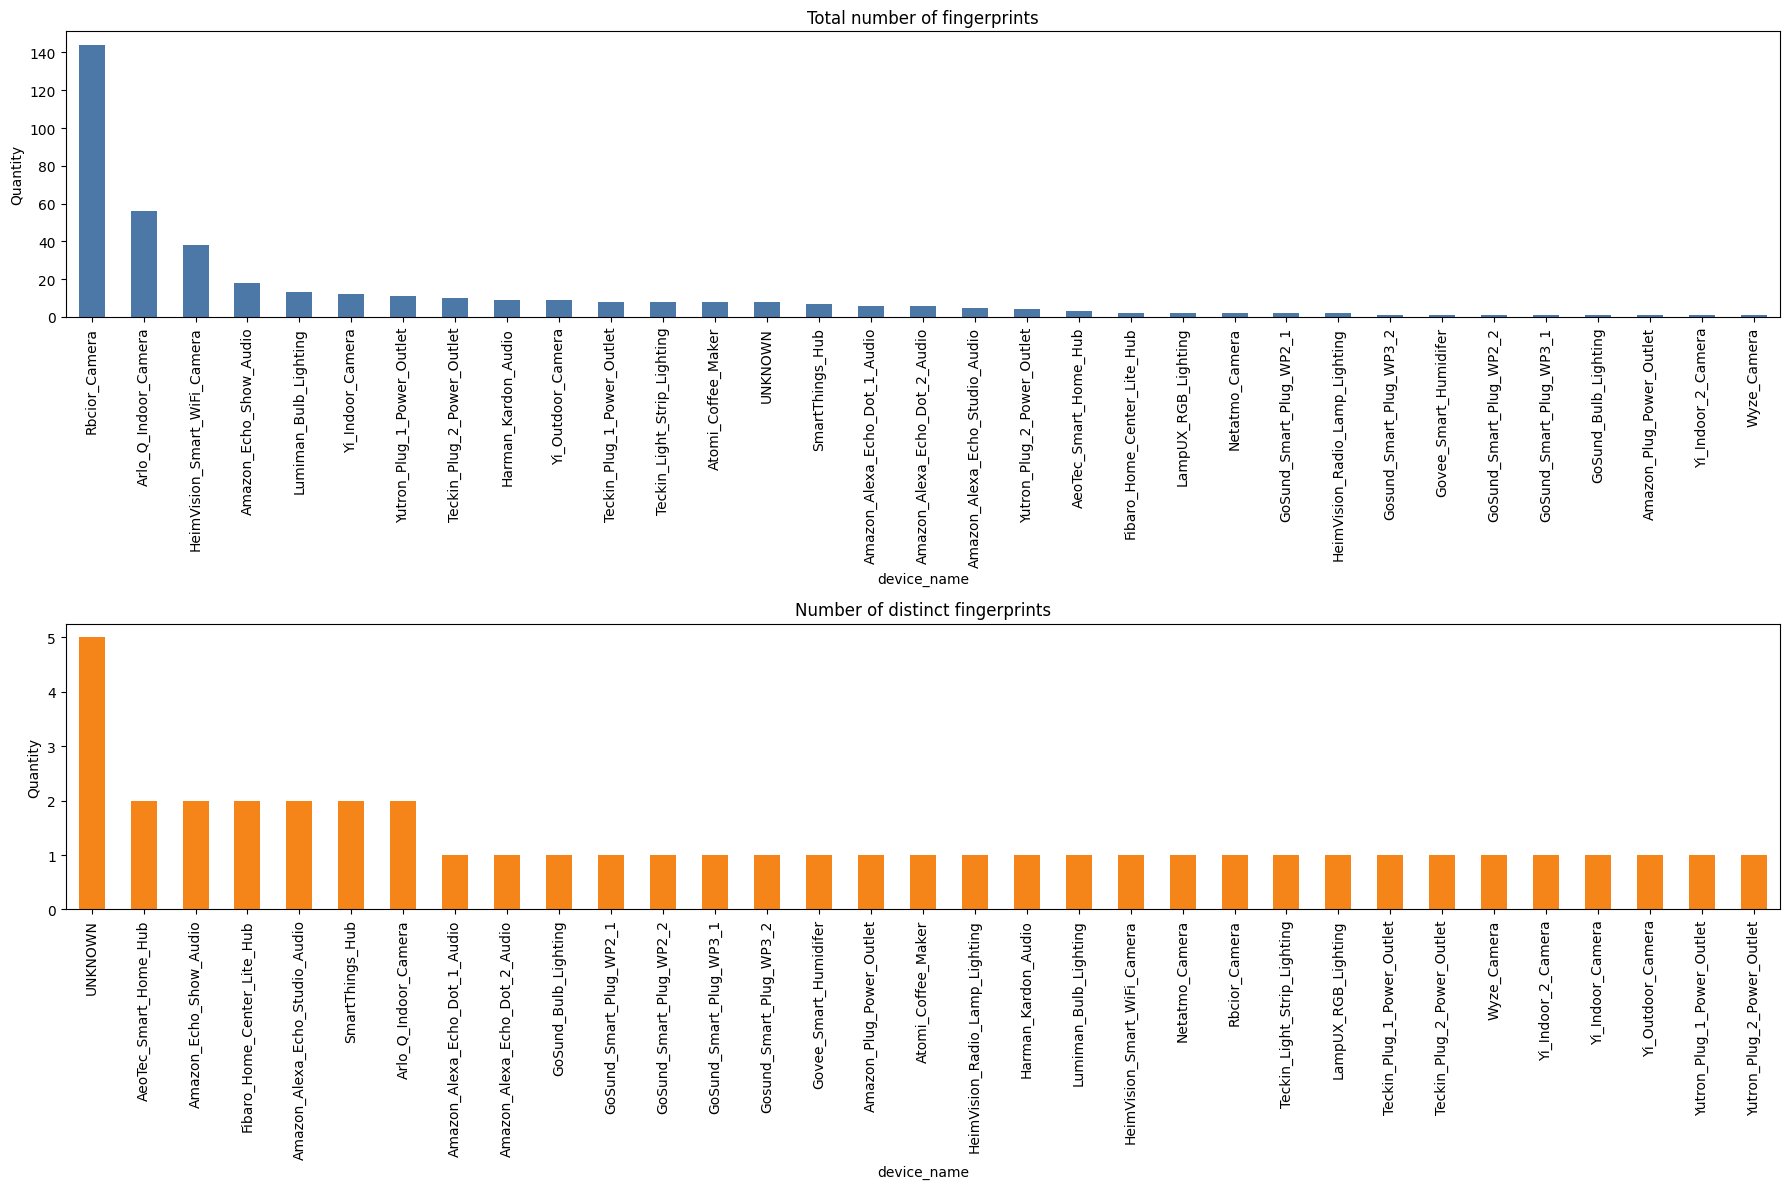

In [2]:
import os

import matplotlib.pyplot as plt

total_fingerprints = df.groupby("device_name")["ja4"].count().sort_values(ascending=False)
distinct_fingerprints = df.groupby("device_name")["ja4"].nunique().sort_values(ascending=False)

print("Total number of fingerprints")
print(total_fingerprints.to_string())
print()
print("Number of distinct fingerprints")
print(distinct_fingerprints.to_string())

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

total_fingerprints.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Total number of fingerprints")
axes[0].set_xlabel("device_name")
axes[0].set_ylabel("Quantity")
axes[0].tick_params(axis="x", rotation=90)

distinct_fingerprints.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Number of distinct fingerprints")
axes[1].set_xlabel("device_name")
axes[1].set_ylabel("Quantity")
axes[1].tick_params(axis="x", rotation=90)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\sample_and_signature_counts.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

### 1.2 Model filtering on minimum and maximum samples per device

In [3]:
# Sample thresholds per device.
min_samples_per_device = 3
max_samples_per_device = 60

device_counts = df["device_name"].value_counts()
valid_devices = device_counts[device_counts >= min_samples_per_device].index

df = df[df["device_name"].isin(valid_devices)]

if max_samples_per_device is not None:
    df = (
        df.groupby("device_name", group_keys=False)
        .head(max_samples_per_device)
        .reset_index(drop=True)
    )
else:
    df = df.reset_index(drop=True)

filtered_counts = df["device_name"].value_counts().sort_values(ascending=False)

print("Number of records per device_name after filtering")
print(filtered_counts.to_string())
print()
print(f"Number of devices kept: {len(valid_devices)}")
print(f"Total number of records after filtering: {len(df)}")
print()
print(df.head())

Number of records per device_name after filtering
device_name
Rbcior_Camera                     60
Arlo_Q_Indoor_Camera              56
HeimVision_Smart_WiFi_Camera      38
Amazon_Echo_Show_Audio            18
Lumiman_Bulb_Lighting             13
Yi_Indoor_Camera                  12
Yutron_Plug_1_Power_Outlet        11
Teckin_Plug_2_Power_Outlet        10
Harman_Kardon_Audio                9
Yi_Outdoor_Camera                  9
Atomi_Coffee_Maker                 8
Teckin_Light_Strip_Lighting        8
UNKNOWN                            8
Teckin_Plug_1_Power_Outlet         8
SmartThings_Hub                    7
Amazon_Alexa_Echo_Dot_2_Audio      6
Amazon_Alexa_Echo_Dot_1_Audio      6
Amazon_Alexa_Echo_Studio_Audio     5
Yutron_Plug_2_Power_Outlet         4
AeoTec_Smart_Home_Hub              3

Number of devices kept: 20
Total number of records after filtering: 299

                  device_name                                   ja4  \
0               Rbcior_Camera  t12d040600_39def8a70f7

## 2. Data preprocessing

This section converts the selected parsed fingerprint fields into numerical features that can be used by the multiclass Random Forest model.

### 2.1 Feature encoding

The following steps convert the JA4 variables into a representation suitable for multiclass RandomForest classification.

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import time

feature_columns = [
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_n_extensions",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    "ja4ts_window_size",
    "ja4ts_option_list",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
]
target_column = "device_name"

categorical_features = [
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    "ja4ts_option_list",
]
numeric_features = [
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4s_n_extensions",
    "ja4ts_window_size",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
]

# Replicate filtering and preparation with new thresholds
df_model = df[feature_columns + [target_column]].copy()

for column in categorical_features + [target_column]:
    df_model[column] = (
        df_model[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

for column in numeric_features:
    df_model[column] = pd.to_numeric(df_model[column], errors="coerce")

df_model = df_model.dropna(subset=numeric_features).reset_index(drop=True)

### 2.2 Dataset composition

In [5]:
# Custom per-device split
X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

unique_devices = df_model[target_column].unique()

for device in unique_devices:
    device_mask = df_model[target_column] == device
    X_device = X[device_mask].reset_index(drop=True)
    y_device = y[device_mask].reset_index(drop=True)
    
    # Split: 80% train, 20% test
    X_train_device, X_test_device, y_train_device, y_test_device = train_test_split(
        X_device, y_device, test_size=0.2, random_state=42, shuffle=True
    )
    
    X_train_list.append(X_train_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_test_list.append(y_test_device)

X_train_raw = pd.concat(X_train_list, ignore_index=True)
X_test_raw = pd.concat(X_test_list, ignore_index=True)
y_train_raw = pd.concat(y_train_list, ignore_index=True)
y_test_raw = pd.concat(y_test_list, ignore_index=True)

# One-hot encoding
X_train = pd.get_dummies(
    X_train_raw, columns=categorical_features, dtype=np.int8,
    dummy_na=False, drop_first=False, prefix_sep="="
)
X_test = pd.get_dummies(
    X_test_raw, columns=categorical_features, dtype=np.int8,
    dummy_na=False, drop_first=False, prefix_sep="="
)

# Align one-hot encoded columns across train, validation, and test
union_columns = set(X_train.columns) | set(X_test.columns)
for col in union_columns:
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

X_train = X_train[sorted(union_columns)]
X_test = X_test[sorted(union_columns)]

# Label encoding
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print("\n\n" + "="*80)
print(f"CONFIGURATION: min_samples={min_samples_per_device}, max_samples={max_samples_per_device}")
print("="*80)

print(f"Target classes after filtering (Devices): {len(class_names)}")
print(f"Samples after filtering: {len(df_model)}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Classes: {len(class_names)}, Features: {X_train.shape[1]}")
print()



CONFIGURATION: min_samples=3, max_samples=60
Target classes after filtering (Devices): 20
Samples after filtering: 299
Train: 231, Test: 68
Classes: 20, Features: 97



## 3. Model Training
Random Forest hyperparameter tuning with GridSearchCV

In [6]:
from sklearn.metrics import make_scorer, f1_score

# GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt'],
    'class_weight': ['balanced'],
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=macro_f1_scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
)

print(f"Running GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"GridSearch completed in {elapsed:.1f} sec")

rf_model = grid_search.best_estimator_
print(f"\nBest GridSearch parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

Running GridSearchCV...


C:\Users\gemma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


GridSearch completed in 21.3 sec

Best GridSearch parameters:
  - class_weight: balanced
  - max_depth: 20
  - max_features: sqrt
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 100


## 4. Evaluation and Results

This section evaluates the final model on the test split, including the confusion matrix and the precision, recall, and F1-score values reported by sklearn.metrics.classification_report().

In [7]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    classification_report,
)

# Predictions and probabilities for each split
train_predictions = rf_model.predict(X_train)
train_probabilities = rf_model.predict_proba(X_train)

test_predictions = rf_model.predict(X_test)
test_probabilities = rf_model.predict_proba(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Precision
train_precision = precision_score(y_train, train_predictions, average='macro', zero_division=0)
test_precision = precision_score(y_test, test_predictions, average='macro', zero_division=0)

# Recall
train_recall = recall_score(y_train, train_predictions, average='macro', zero_division=0)
test_recall = recall_score(y_test, test_predictions, average='macro', zero_division=0)

# Macro F1 
train_f1_macro = f1_score(y_train, train_predictions, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, test_predictions, average='macro', zero_division=0)

# Top-k accuracy
top_3_k = min(3, len(class_names))
top_5_k = min(5, len(class_names))

if len(class_names) <= top_3_k:
    test_top_3_accuracy = 1.0
else:
    test_top_3_accuracy = top_k_accuracy_score(
        y_test, test_probabilities, k=top_3_k, labels=np.arange(len(class_names))
    )

if len(class_names) <= top_5_k:
    test_top_5_accuracy = 1.0
else:
    test_top_5_accuracy = top_k_accuracy_score(
        y_test, test_probabilities, k=top_5_k, labels=np.arange(len(class_names))
    )

# Per-sample prediction timing
prediction_times = []
for sample_index in range(len(X_test)):
    sample_features = X_test.iloc[[sample_index]]
    start_time = time.perf_counter()
    rf_model.predict_proba(sample_features)
    elapsed_time = time.perf_counter() - start_time
    prediction_times.append(elapsed_time)

average_prediction_time = float(np.mean(prediction_times))
all_labels = np.arange(len(class_names))

print("="*80)
print("GENERAL RESULTS")
print("="*80)
print("\nAccuracy:")
print(f"  - Train: {train_accuracy:.4f}")
print(f"  - Test:  {test_accuracy:.4f}")

print("\nPrecision:")
print(f"  - Train: {train_precision:.4f}")
print(f"  - Test:  {test_precision:.4f}")

print("\nRecall:")
print(f"  - Train: {train_recall:.4f}")
print(f"  - Test:  {test_recall:.4f}")

print("\nMacro F1 Score:")
print(f"  - Train: {train_f1_macro:.4f}")
print(f"  - Test:  {test_f1_macro:.4f}")

print("\nTop-k accuracy on the test split:")
print(f"  - top_{top_3_k}_accuracy: {test_top_3_accuracy:.4f}")
print(f"  - top_{top_5_k}_accuracy: {test_top_5_accuracy:.4f}")

print(f"\nAverage prediction time: {average_prediction_time:.6f} s ({average_prediction_time * 1000:.3f} ms)")

print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST")
print("="*80)
print(
    classification_report(
        y_test,
        test_predictions,
        labels=all_labels,
        target_names=class_names,
        zero_division=0,
    )
)

GENERAL RESULTS

Accuracy:
  - Train: 0.8398
  - Test:  0.7941

Precision:
  - Train: 0.6340
  - Test:  0.5558

Recall:
  - Train: 0.7027
  - Test:  0.6375

Macro F1 Score:
  - Train: 0.6396
  - Test:  0.5741

Top-k accuracy on the test split:
  - top_3_accuracy: 0.9265
  - top_5_accuracy: 1.0000

Average prediction time: 0.029076 s (29.076 ms)

CLASSIFICATION REPORT - TEST
                                precision    recall  f1-score   support

         aeotec_smart_home_hub       0.00      0.00      0.00         1
 amazon_alexa_echo_dot_1_audio       1.00      1.00      1.00         2
 amazon_alexa_echo_dot_2_audio       1.00      1.00      1.00         2
amazon_alexa_echo_studio_audio       0.00      0.00      0.00         1
        amazon_echo_show_audio       0.75      0.75      0.75         4
          arlo_q_indoor_camera       1.00      1.00      1.00        12
            atomi_coffee_maker       0.00      0.00      0.00         2
           harman_kardon_audio       1.00     

### Confusion matrix

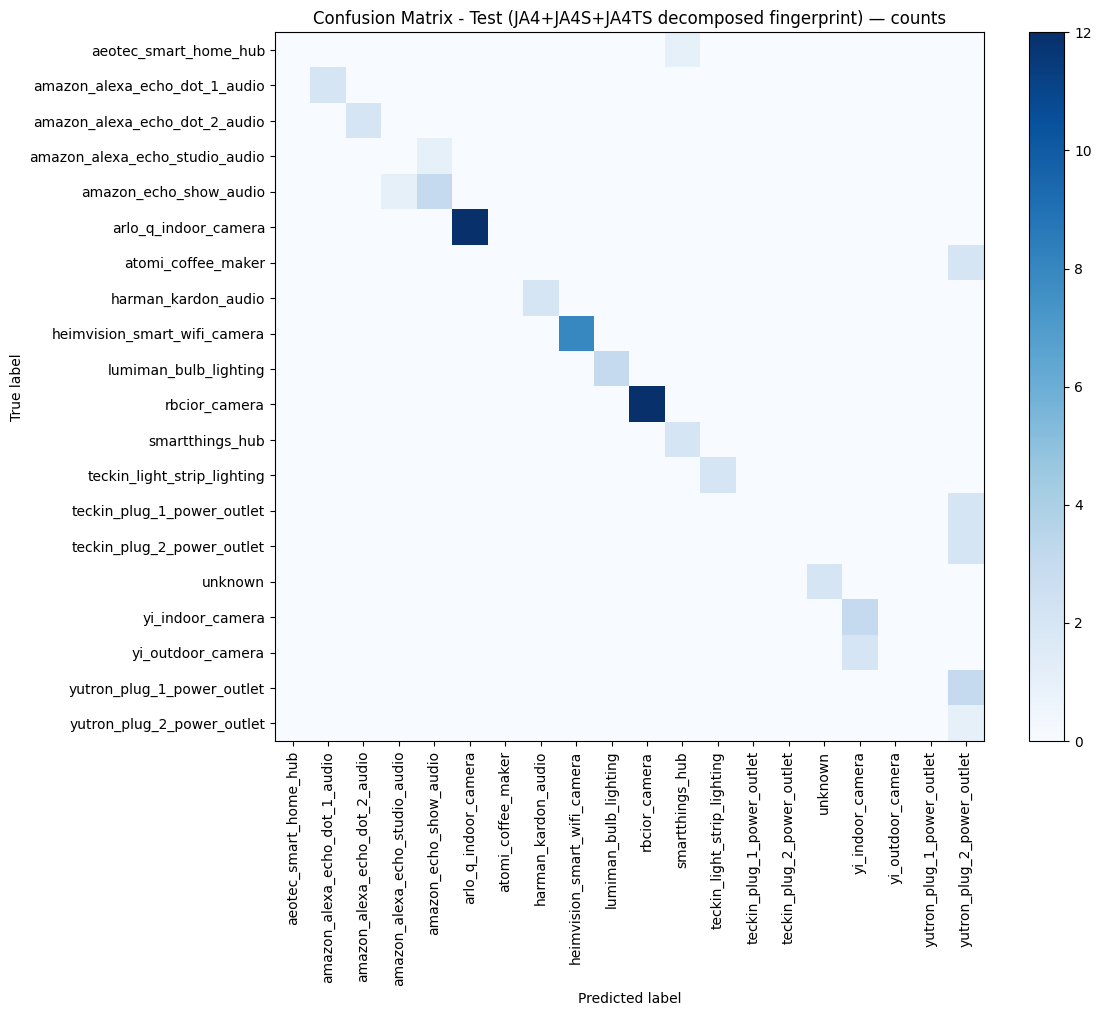

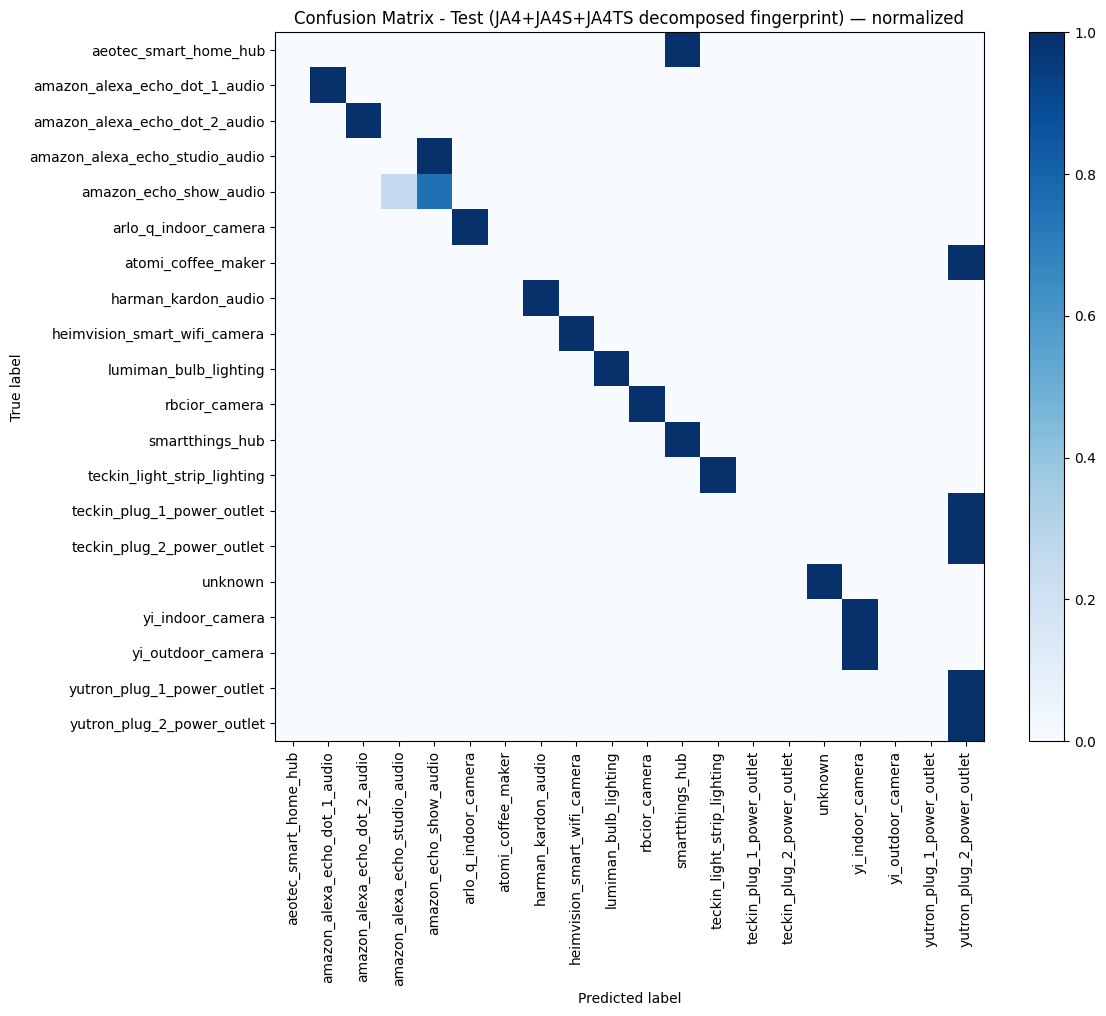

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

feature_set_label = "JA4+JA4S+JA4TS decomposed fingerprint"
base_path = r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
out_dir = rf"{base_path}\rf_full_fingerprints\rf_ja4+ja4s+ja4ts_decomposed"
os.makedirs(out_dir, exist_ok=True)

# Confusion matrix (counts)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)
ax.set_title(f"Confusion Matrix - Test ({feature_set_label}) — counts")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix_counts.pdf"), format="pdf", bbox_inches="tight")
plt.show()

# Confusion matrix (normalized by true class)
denom = cm.sum(axis=1)[:, np.newaxis]
denom[denom == 0] = 1
cm_norm = cm.astype(float) / denom
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp_norm.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)
ax.set_title(f"Confusion Matrix - Test ({feature_set_label}) — normalized")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix_normalized.pdf"), format="pdf", bbox_inches="tight")
plt.show()

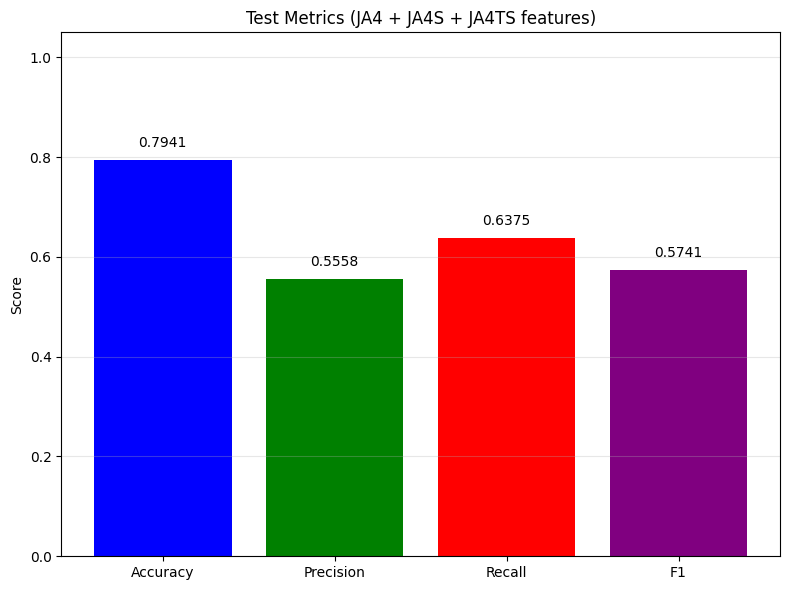

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [test_accuracy, test_precision, test_recall, test_f1_macro]

feature_set_label = 'JA4 + JA4S + JA4TS features'
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple'])
plt.title(f'Test Metrics ({feature_set_label})')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\test_metrics.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

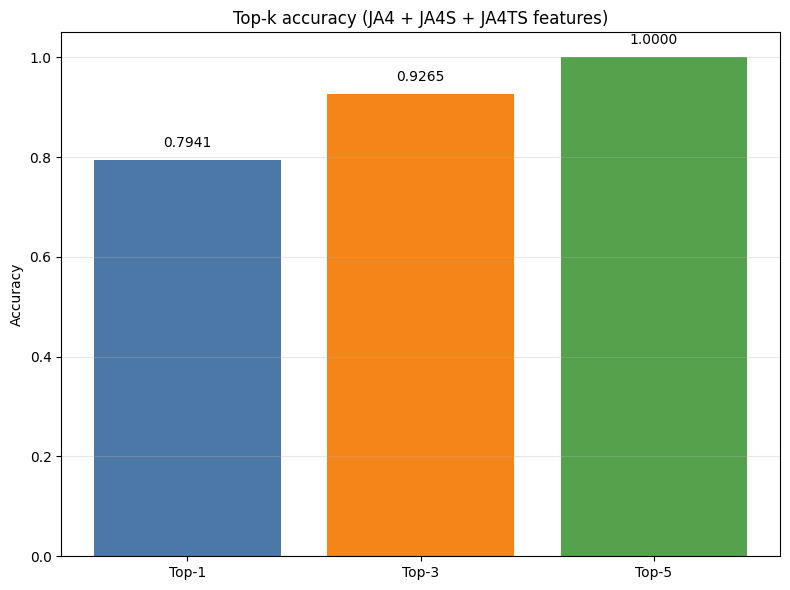

In [10]:
top_k_labels = ['Top-1', 'Top-3', 'Top-5']
top_k_values = [test_accuracy, test_top_3_accuracy, test_top_5_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_labels, top_k_values, color=['#4C78A8', '#F58518', '#54A24B'])
plt.title(f'Top-k accuracy ({feature_set_label})')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\top_k_accuracy.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

### 4.1 Feature Importance

Top original features by cumulative importance:
       grouped_feature  importance
       ja4_cipher_hash    0.210413
    ja4_extension_hash    0.171437
   ja4s_extension_hash    0.113635
         ja4_n_ciphers    0.073074
      ja4_n_extensions    0.063249
    ja4s_cipher_chosen    0.056115
     ja4ts_option_list    0.044772
              ja4_alpn    0.044196
     ja4s_n_extensions    0.041304
           ja4ts_scale    0.032552
     ja4ts_window_size    0.024087
          ja4_sni_type    0.021343
             ja4s_alpn    0.021101
     ja4ts_num_options    0.017952
             ja4ts_mss    0.016276
       ja4_tls_version    0.015479
        ja4ts_has_sack    0.010941
ja4ts_has_window_scale    0.008831
      ja4s_tls_version    0.007923
   ja4ts_has_timestamp    0.005319


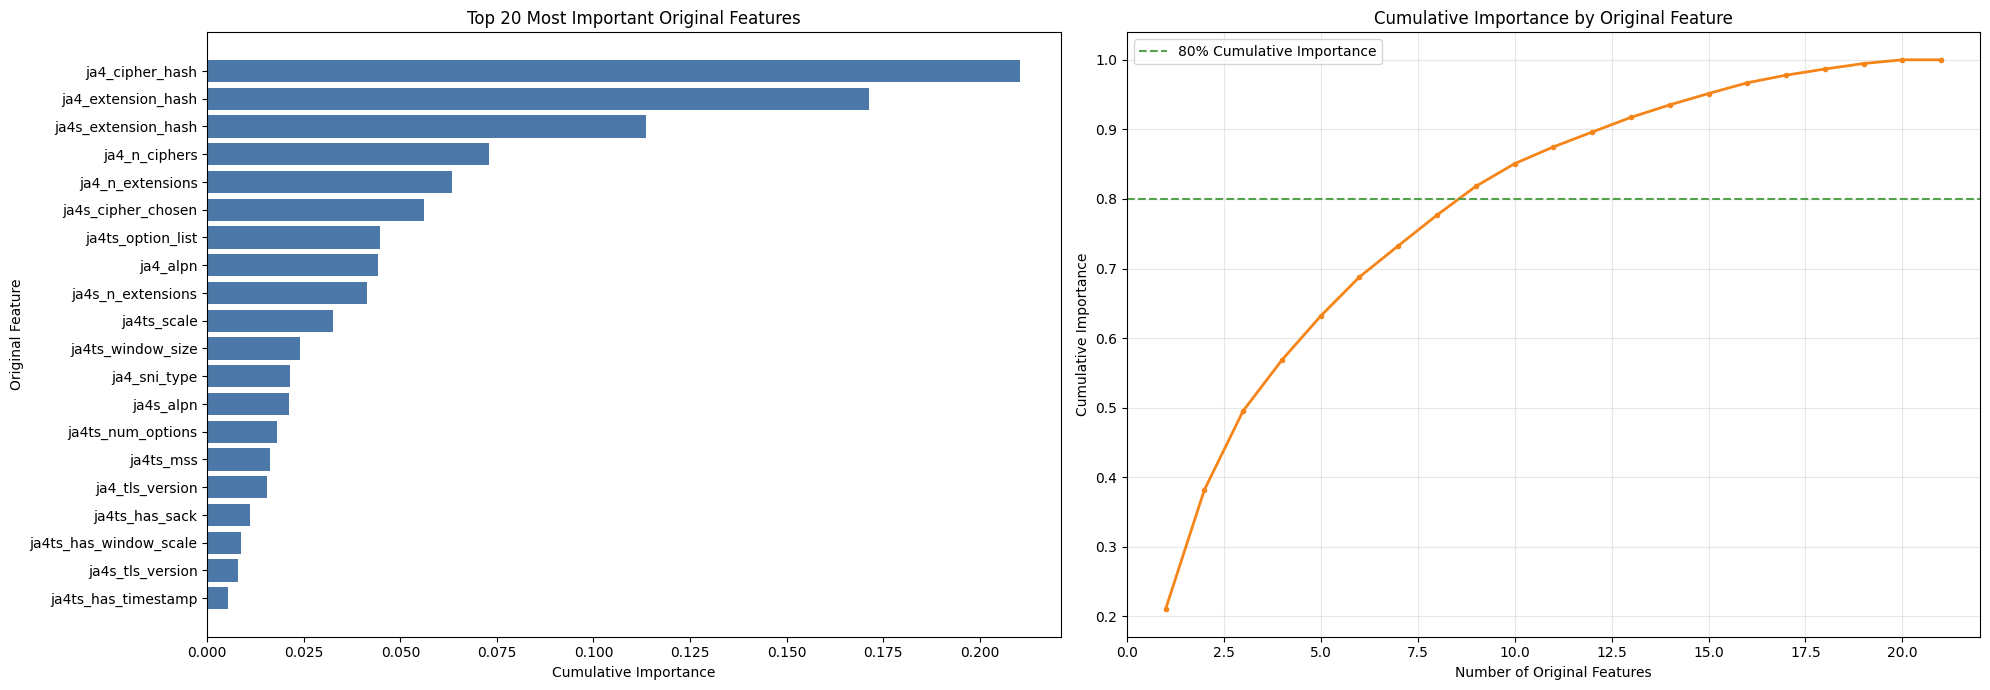

In [11]:
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

grouped_feature_importance_df = (
    feature_importance_df.assign(
        grouped_feature=feature_importance_df["feature"].str.split("=", n=1).str[0]
    )
    .groupby("grouped_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_n = min(20, len(grouped_feature_importance_df))
top_features = grouped_feature_importance_df.head(top_n).sort_values("importance")
cumulative_importance = grouped_feature_importance_df["importance"].cumsum().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].barh(top_features["grouped_feature"], top_features["importance"], color="#4C78A8")
axes[0].set_title(f"Top {top_n} Most Important Original Features")
axes[0].set_xlabel("Cumulative Importance")
axes[0].set_ylabel("Original Feature")

axes[1].plot(
    range(1, len(cumulative_importance) + 1),
    cumulative_importance,
    color="#F58518",
    linewidth=2,
    marker="o",
    markersize=3,
    markevery=max(1, len(cumulative_importance) // 25),
)
axes[1].axhline(0.8, color="#54A24B", linestyle="--", label="80% Cumulative Importance")
axes[1].set_title("Cumulative Importance by Original Feature")
axes[1].set_xlabel("Number of Original Features")
axes[1].set_ylabel("Cumulative Importance")
axes[1].legend()
axes[1].grid(alpha=0.3)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\feature_importance.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

print("Top original features by cumulative importance:")
print(grouped_feature_importance_df.head(20).to_string(index=False))

### 4.2 Save the Trained Model

In [12]:
import joblib
import json
from pathlib import Path

project_root = Path(r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate")
if not project_root.exists():
    project_root = Path("/mnt/d/TFG_GemmaBeatrizVate")

model_dir = project_root / "3_Results" / "models" / "rf_ja4+ja4s+ja4ts_decomposed_gridsearch"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "model.joblib"
joblib.dump(rf_model, model_path)

artifacts = {
    "experiment": "rf_ja4+ja4s+ja4ts_decomposed_gridsearch",
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "class_names": class_names.tolist(),
    "best_params": grid_search.best_params_,
    "best_cv_macro_f1": float(grid_search.best_score_),
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "min_samples_per_device": int(min_samples_per_device),
    "max_samples_per_device": None if min_samples_per_device is None else int(min_samples_per_device),
}

artifacts_path = model_dir / "artifacts.json"
with artifacts_path.open("w", encoding="utf-8") as file:
    json.dump(artifacts, file, indent=2)

print(f"Model saved to: {model_path}")
print(f"Artifacts saved to: {artifacts_path}")

Model saved to: C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\models\rf_ja4+ja4s+ja4ts_decomposed_gridsearch\model.joblib
Artifacts saved to: C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\models\rf_ja4+ja4s+ja4ts_decomposed_gridsearch\artifacts.json


## 5. Top-Feature Retraining

This section selects the most important original features from the full model, rebuilds the pipeline using only those features, and compares the results against the model trained with the full feature set.

### 5.1 Dataset composition 

In [13]:
top_feature_count = 13
top_features = grouped_feature_importance_df['grouped_feature'].head(top_feature_count).tolist()
print('Features used in the top-feature retraining experiment:', top_features)
print('Using the same hyperparameters as the original model and no additional features.')

df_top = df_model[top_features + [target_column]].copy()

for column in top_features:
    if column in categorical_features:
        df_top[column] = df_top[column].fillna('unknown').astype(str).str.strip().str.lower()
    elif column in numeric_features:
        df_top[column] = pd.to_numeric(df_top[column], errors='coerce')
    else:
        df_top[column] = df_top[column].fillna('unknown').astype(str).str.strip().str.lower()

numeric_subset = [c for c in top_features if c in numeric_features]
if numeric_subset:
    df_top = df_top.dropna(subset=numeric_subset).reset_index(drop=True)

top_device_counts = df_top[target_column].value_counts()
valid_devices_top = top_device_counts[top_device_counts >= min_samples_per_device].index
if len(valid_devices_top) != len(top_device_counts):
    print(f'Categories excluded after top-feature filtering: {len(top_device_counts) - len(valid_devices_top)}')
df_top = df_top[df_top[target_column].isin(valid_devices_top)].reset_index(drop=True)

print(f'Categories kept after using the top {top_feature_count} features: {len(valid_devices_top)}')
print(f'Total samples after top-feature filtering: {len(df_top)}')

X_top = df_top[top_features].copy()
y_top = df_top[target_column].copy()

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

for device in valid_devices_top:
    device_mask = df_top[target_column] == device
    X_device = X_top[device_mask].reset_index(drop=True)
    y_device = y_top[device_mask].reset_index(drop=True)

    X_train_device, X_test_device, y_train_device, y_test_device = train_test_split(
        X_device, y_device, test_size=0.2, random_state=42, shuffle=True
    )

    X_train_list.append(X_train_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_test_list.append(y_test_device)

X_train_top = pd.concat(X_train_list, ignore_index=True)
X_test_top = pd.concat(X_test_list, ignore_index=True)
y_train_top = pd.concat(y_train_list, ignore_index=True)
y_test_top = pd.concat(y_test_list, ignore_index=True)

categorical_top = [c for c in top_features if c in categorical_features]
X_train_top = pd.get_dummies(X_train_top, columns=categorical_top, dtype=np.int8, dummy_na=False, drop_first=False, prefix_sep='=')
X_test_top = pd.get_dummies(X_test_top, columns=categorical_top, dtype=np.int8, dummy_na=False, drop_first=False, prefix_sep='=')

union_columns_top = set(X_train_top.columns) | set(X_test_top.columns)
for col in union_columns_top:
    if col not in X_train_top.columns:
        X_train_top[col] = 0
    if col not in X_test_top.columns:
        X_test_top[col] = 0

X_train_top = X_train_top[sorted(union_columns_top)]
X_test_top = X_test_top[sorted(union_columns_top)]

label_encoder_top = LabelEncoder()
y_train_top = label_encoder_top.fit_transform(y_train_top)
y_test_top = label_encoder_top.transform(y_test_top)

Features used in the top-feature retraining experiment: ['ja4_cipher_hash', 'ja4_extension_hash', 'ja4s_extension_hash', 'ja4_n_ciphers', 'ja4_n_extensions', 'ja4s_cipher_chosen', 'ja4ts_option_list', 'ja4_alpn', 'ja4s_n_extensions', 'ja4ts_scale', 'ja4ts_window_size', 'ja4_sni_type', 'ja4s_alpn']
Using the same hyperparameters as the original model and no additional features.
Categories kept after using the top 13 features: 20
Total samples after top-feature filtering: 299


### 5.2 Model Training

In [14]:
rf_top = RandomForestClassifier(**{**grid_search.best_params_, 'random_state': 42, 'n_jobs': -1})
rf_top.fit(X_train_top, y_train_top)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 5.3 Results

In [15]:
test_predictions_top = rf_top.predict(X_test_top)
test_accuracy_top = accuracy_score(y_test_top, test_predictions_top)
test_f1_top = f1_score(y_test_top, test_predictions_top, average='macro', zero_division=0)
macro_precision_top = precision_score(y_test_top, test_predictions_top, average='macro', zero_division=0)
macro_recall_top = recall_score(y_test_top, test_predictions_top, average='macro', zero_division=0)

if len(label_encoder_top.classes_) <= 3:
    test_top_3_accuracy_top = 1.0
else:
    test_top_3_accuracy_top = top_k_accuracy_score(
        y_test_top, rf_top.predict_proba(X_test_top), k=3, labels=np.arange(len(label_encoder_top.classes_))
    )

if len(label_encoder_top.classes_) <= 5:
    test_top_5_accuracy_top = 1.0
else:
    test_top_5_accuracy_top = top_k_accuracy_score(
        y_test_top, rf_top.predict_proba(X_test_top), k=5, labels=np.arange(len(label_encoder_top.classes_))
    )

print(f'===== Top {top_feature_count} Feature Results =====')
print(f'Test Accuracy: {test_accuracy_top:.4f}')
print(f'Test Precision (macro): {macro_precision_top:.4f}')
print(f'Test Recall (macro): {macro_recall_top:.4f}')
print(f'Test F1 (macro): {test_f1_top:.4f}')
print(f'Top-3 Accuracy: {test_top_3_accuracy_top:.4f}')
print(f'Top-5 Accuracy: {test_top_5_accuracy_top:.4f}')

all_results = {
    'accuracy': test_accuracy,
    'precision': test_precision,
    'recall': test_recall,
    'f1': test_f1_macro,
    'top_3': test_top_3_accuracy,
    'top_5': test_top_5_accuracy,
}
top_results = {
    'accuracy': test_accuracy_top,
    'precision': macro_precision_top,
    'recall': macro_recall_top,
    'f1': test_f1_top,
    'top_3': test_top_3_accuracy_top,
    'top_5': test_top_5_accuracy_top,
}

print("\n")
print(f'===== Comparison: All Features vs Top {top_feature_count} Features =====')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    diff = top_results[metric] - all_results[metric]
    sign = '+' if diff >= 0 else '-'
    print(f'{metric.capitalize():>9}: all={all_results[metric]:.4f}, top{top_feature_count}={top_results[metric]:.4f}, diff={sign}{abs(diff):.4f}')
print(f"    Top-3 Accuracy: all={all_results['top_3']:.4f}, top{top_feature_count}={top_results['top_3']:.4f}")
print(f"    Top-5 Accuracy: all={all_results['top_5']:.4f}, top{top_feature_count}={top_results['top_5']:.4f}")

===== Top 13 Feature Results =====
Test Accuracy: 0.7794
Test Precision (macro): 0.5470
Test Recall (macro): 0.6333
Test F1 (macro): 0.5686
Top-3 Accuracy: 0.9118
Top-5 Accuracy: 1.0000


===== Comparison: All Features vs Top 13 Features =====
 Accuracy: all=0.7941, top13=0.7794, diff=-0.0147
Precision: all=0.5558, top13=0.5470, diff=-0.0088
   Recall: all=0.6375, top13=0.6333, diff=-0.0042
       F1: all=0.5741, top13=0.5686, diff=-0.0055
    Top-3 Accuracy: all=0.9265, top13=0.9118
    Top-5 Accuracy: all=1.0000, top13=1.0000


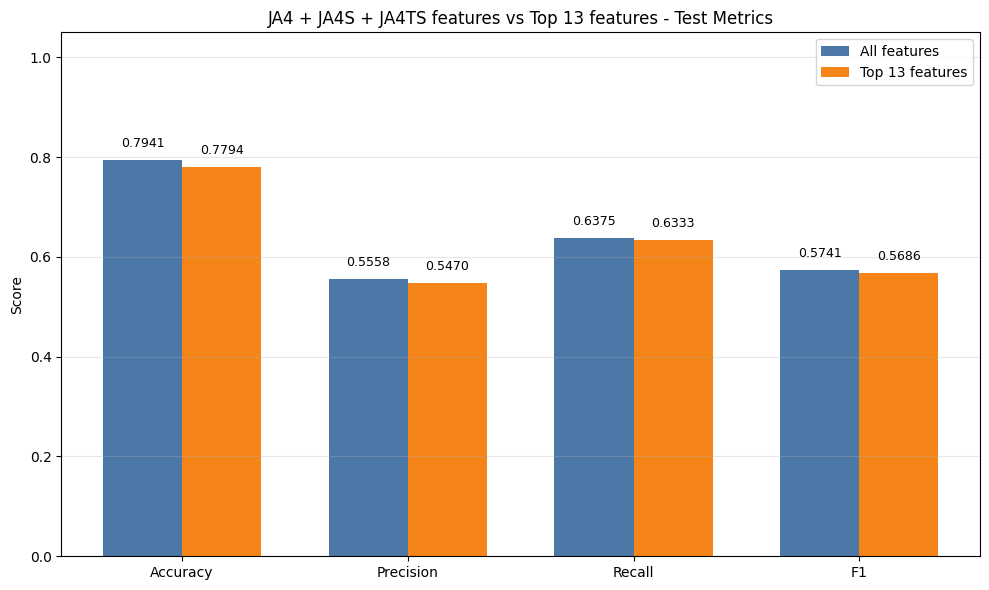

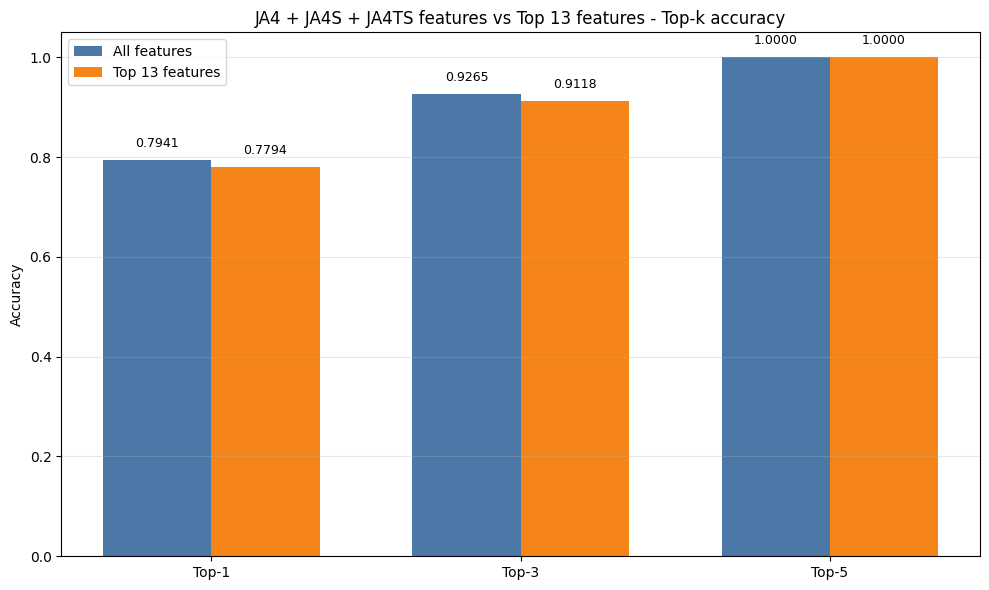

In [16]:
labels = ['Accuracy', 'Precision', 'Recall', 'F1']
all_values = [all_results[m] for m in ['accuracy', 'precision', 'recall', 'f1']]
top_values = [top_results[m] for m in ['accuracy', 'precision', 'recall', 'f1']]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, all_values, width, label='All features', color='#4C78A8')
plt.bar(x + width / 2, top_values, width, label=f'Top {top_feature_count} features', color='#F58518')
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.title(f'JA4 + JA4S + JA4TS features vs Top {top_feature_count} features - Test Metrics')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
for i in range(len(labels)):
    plt.text(x[i] - width / 2, all_values[i] + 0.02, f'{all_values[i]:.4f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width / 2, top_values[i] + 0.02, f'{top_values[i]:.4f}', ha='center', va='bottom', fontsize=9)
plt.legend()

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\features_vs_top_features_test_metrics.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

labels_topk = ['Top-1', 'Top-3', 'Top-5']
all_values_topk = [all_results['accuracy'], all_results['top_3'], all_results['top_5']]
top_values_topk = [top_results['accuracy'], top_results['top_3'], top_results['top_5']]

x = np.arange(len(labels_topk))
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, all_values_topk, width, label='All features', color='#4C78A8')
plt.bar(x + width / 2, top_values_topk, width, label=f'Top {top_feature_count} features', color='#F58518')
plt.xticks(x, labels_topk)
plt.ylim(0, 1.05)
plt.title(f'JA4 + JA4S + JA4TS features vs Top {top_feature_count} features - Top-k accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
for i in range(len(labels_topk)):
    plt.text(x[i] - width / 2, all_values_topk[i] + 0.02, f'{all_values_topk[i]:.4f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width / 2, top_values_topk[i] + 0.02, f'{top_values_topk[i]:.4f}', ha='center', va='bottom', fontsize=9)
plt.legend()

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_features\rf_ja4+ja4s+ja4ts_decomposed\features_vs_top_features_topk.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")